In [1]:
print("Hello World")

Hello World


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [4]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.shape


(8807, 12)

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [23]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [ ]:
df['director'].duplicated().any()


np.True_

In [38]:
df['rating'].duplicated().any()

np.True_

In [ ]:
# comparing with type to fill missingf with mode of the rating 
df.groupby('type')['rating'].value_counts()

type     rating  
Movie    TV-MA       2062
         TV-14       1427
         R            797
         TV-PG        540
         PG-13        490
         PG           287
         TV-Y7        139
         TV-Y         131
         TV-G         126
         NR            75
         G             41
         TV-Y7-FV       5
         UR             3
         NC-17          3
         84 min         1
         66 min         1
         74 min         1
TV Show  TV-MA       1145
         TV-14        733
         TV-PG        323
         TV-Y7        195
         TV-Y         176
         TV-G          94
         NR             5
         R              2
         TV-Y7-FV       1
Name: count, dtype: int64

In [45]:
df.groupby('type')['rating'].agg(lambda x: x.mode()[0])

type
Movie      TV-MA
TV Show    TV-MA
Name: rating, dtype: str

In [46]:
df['rating'] = df.groupby('type')['rating'].transform(lambda x: x.fillna(x.mode()[0]))

In [49]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             0
duration           3
listed_in          0
description        0
dtype: int64

In [51]:
#next doing for duration 

df[['duration_value','duration_unit']] = df['duration'].str.split(' ', expand=True)

In [56]:
df[['duration_value','duration_unit']]

,duration_value,duration_unit
0,90,min
1,2,Seasons
2,1,Season
3,1,Season
4,2,Seasons
...,...,...
8802,158,min
8803,2,Seasons
8804,88,min
8805,88,min


In [57]:
#convert str to numericals
df['duration_value'] = pd.to_numeric(df['duration_value'], errors='coerce')

In [58]:
movie_median = df[df['type']=='Movie']['duration_value'].median()
tv_median = df[df['type']=='TV Show']['duration_value'].median()

In [ ]:
#filling values

df.loc[(df['type']=='Movie') & (df['duration_value'].isnull()), 'duration_value'] = movie_median

df.loc[(df['type']=='TV Show') & (df['duration_value'].isnull()), 'duration_value'] = tv_median

In [62]:
df['duration_value'].isnull().sum()

np.int64(0)

In [ ]:
#now for date added
#Remove leading/trailing space
df['date_added'] = df['date_added'].str.strip()

In [69]:
df['date_added'] = pd.to_datetime(df['date_added'])

In [77]:
df['added_year'] = df['date_added'].dt.year

In [78]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_value,duration_unit,added_year,added_month
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0,min,2021.0,9.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2.0,Seasons,2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1.0,Season,2021.0,9.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1.0,Season,2021.0,9.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2.0,Seasons,2021.0,9.0


In [ ]:
df.drop('duration', axis=1, inplace=True)
df.drop('added_month', axis=1, inplace=True)


In [80]:
df['duration_value'] = df['duration_value'].astype(int)

In [87]:
df['director'] = df['director'].fillna('unknown')
df['cast'] = df['cast'].fillna('unknown')
df['country'] = df['country'].fillna('unknown')

In [89]:
df.isnull().sum()

show_id            0
type               0
title              0
director           0
cast               0
country            0
date_added        10
release_year       0
rating             0
listed_in          0
description        0
duration_value     0
duration_unit      3
added_year        10
dtype: int64

In [91]:
df.drop('added_year', axis=1, inplace=True)

In [92]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,duration_value,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,Documentaries,"As her father nears the end of his life, filmm...",90,min
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2,Seasons
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1,Season
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,unknown,2021-09-24,2021,TV-MA,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1,Season
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2,Seasons


In [93]:
df.isnull().sum()

show_id            0
type               0
title              0
director           0
cast               0
country            0
date_added        10
release_year       0
rating             0
listed_in          0
description        0
duration_value     0
duration_unit      3
dtype: int64

In [94]:
df.loc[(df['duration_unit'].isnull()) & (df['type'] == 'Movie'), 'duration_unit'] = 'min'

df.loc[(df['duration_unit'].isnull()) & (df['type'] == 'TV Show'), 'duration_unit'] = 'Seasons'

In [95]:
df['duration_unit'].isnull().sum()

np.int64(0)

In [96]:
df = df.dropna(subset=['date_added'])

In [97]:
df.isnull().sum()

show_id           0
type              0
title             0
director          0
cast              0
country           0
date_added        0
release_year      0
rating            0
listed_in         0
description       0
duration_value    0
duration_unit     0
dtype: int64

In [98]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,duration_value,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,Documentaries,"As her father nears the end of his life, filmm...",90,min
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2,Seasons
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1,Season
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,unknown,2021-09-24,2021,TV-MA,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1,Season
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2,Seasons


In [99]:
#EDA

df['type'].value_counts()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

In [100]:
df['rating'].value_counts()

rating
TV-MA       3209
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [101]:
df['country'].value_counts().head(10)

country
United States     2812
India              972
unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

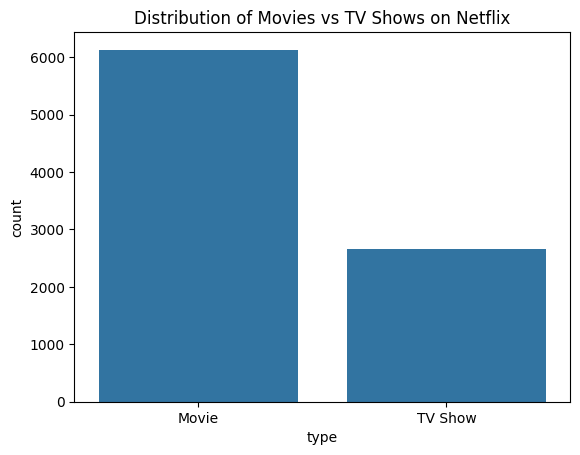

In [ ]:
sns.countplot(x='type', data=df)
plt.title("Distribution of Movies vs TV Shows on Netflix")
plt.show()

#movie is more than tv shows in netflix

In [ ]:
# To check How many titles were released each year
df['release_year'].value_counts().sort_index()

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1146
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

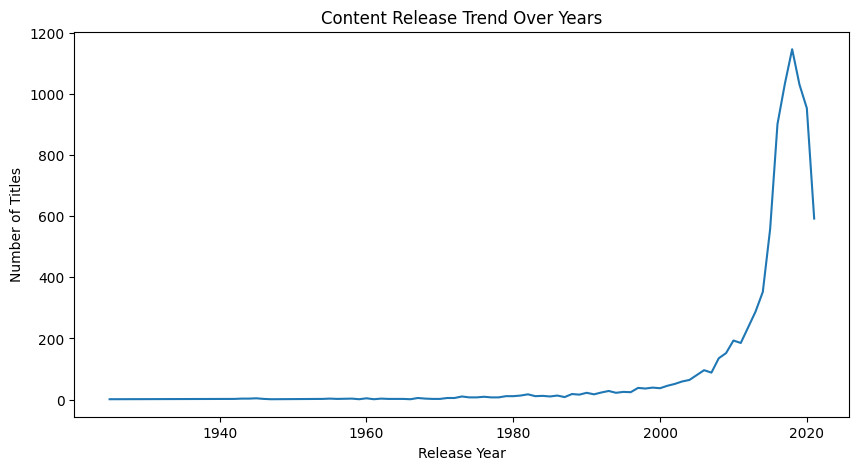

In [118]:
df['release_year'].value_counts().sort_index().plot(figsize=(10,5))
plt.title("Content Release Trend Over Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

In [ ]:
#Top countries producing netflix contents
df['country'].value_counts().head(10)

country
United States     2812
India              972
unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

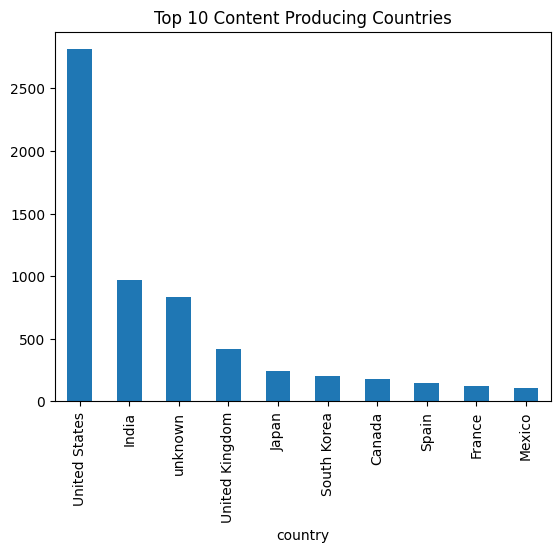

In [111]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Content Producing Countries")
plt.show()

In [112]:
#Most common ratings 
df['rating'].value_counts()

rating
TV-MA       3209
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

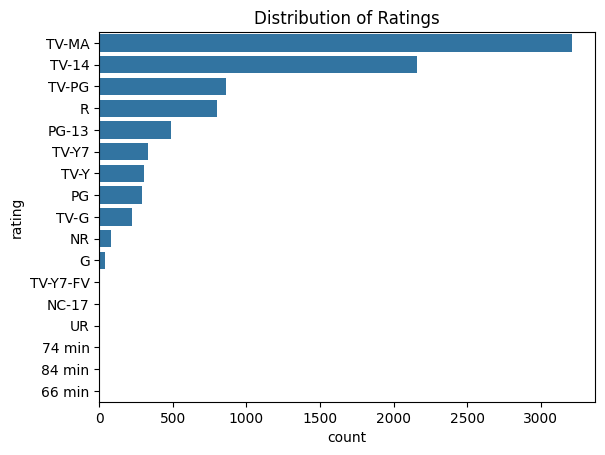

In [113]:
sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index)
plt.title("Distribution of Ratings")
plt.show()

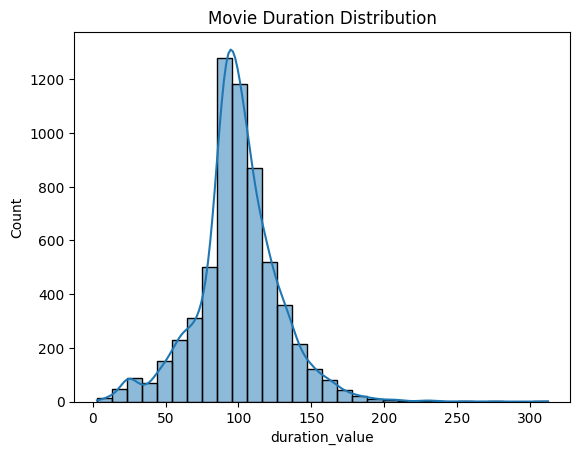

In [114]:
# Movie duration Distribution

movies = df[df['type']=='Movie']

sns.histplot(movies['duration_value'], bins=30, kde=True)
plt.title("Movie Duration Distribution")
plt.show()

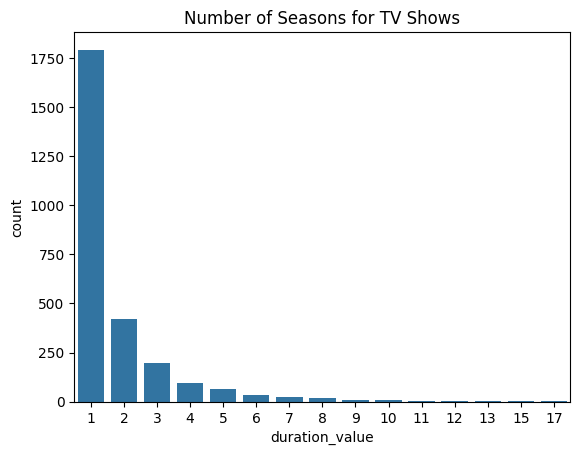

In [115]:
# Netflix series duration

shows = df[df['type']=='TV Show']

sns.countplot(x='duration_value', data=shows)
plt.title("Number of Seasons for TV Shows")
plt.show()

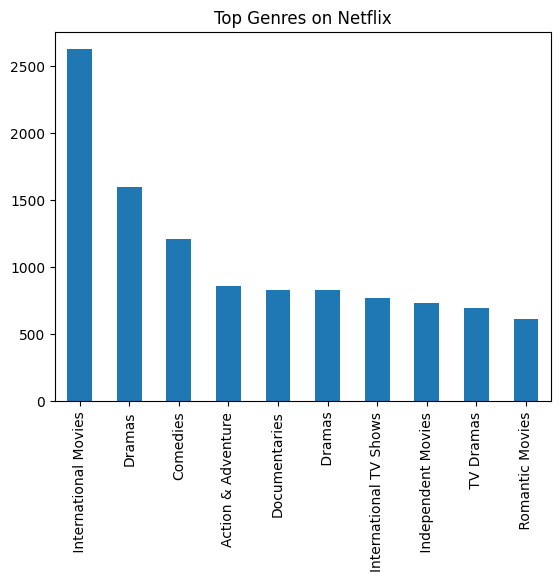

In [ ]:
#geners on Netflix
genres = df['listed_in'].str.split(',', expand=True).stack()

genres.value_counts().head(10).plot(kind='bar')
plt.title("Top Genres on Netflix")
plt.show()